# MICrONS Functional Data: Quick EDA

This notebook opens `microns.h5` with `MicronsReader` and performs a compact exploratory analysis of:
- sessions and available metadata
- stimulus types and hash counts
- trial-level neural and behavior summaries for one example stimulus

## Imports

The MICrONS functional dataset is stored in an HDF5 file. This cell imports the tools used to read the file, organize summaries in tables, and plot aligned neural and behavioral signals.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reader import MicronsReader

## Dataset Location

The functional recordings are packaged in one file, `microns.h5`. This step verifies that the dataset is present locally before reading any sessions, trials, or stimulus metadata.

In [4]:
DATA_PATH = Path('microns.h5')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Could not find dataset at {DATA_PATH.resolve()}')

print(f'Using dataset: {DATA_PATH.resolve()}')

Using dataset: C:\Users\tomma\Desktop\NEUROSCIENCE\neuroscience-project\tommy\microns.h5


## Global Structure

The dataset is organized by session and by stimulus type. Here we count how many sessions are available and how many distinct stimulus hashes exist for each stimulus family.

In [5]:
with MicronsReader(str(DATA_PATH)) as reader:
    sessions = sorted(reader.f['sessions'].keys())
    stim_types = sorted(reader.f['types'].keys())

    print(f'Number of sessions: {len(sessions)}')
    print(f'Stimulus types: {stim_types}')

    # Per type, count unique condition hashes available in index.
    type_counts = {t: len(reader.get_hashes_by_type(t)) for t in stim_types}

pd.Series(type_counts, name='n_hashes').to_frame()

Number of sessions: 14
Stimulus types: ['Clip', 'Monet2', 'Trippy']


,n_hashes
Clip,2112
Monet2,150
Trippy,149


## Session Summary

Each session contains a set of recorded neurons, multiple trials, and brain-area annotations. This table shows how session size and anatomical coverage vary across the dataset.

In [6]:
with MicronsReader(str(DATA_PATH)) as reader:
    # Build a session-level summary table.
    rows = []
    for s in sessions:
        session_hashes = reader.get_hashes_by_session(s, return_unique=False)
        areas = reader.get_available_brain_areas(s)
        n_neurons = len(reader.f[f'sessions/{s}/meta/unit_ids'])
        n_trials = len(reader.f[f'sessions/{s}/trials'])
        rows.append({
            'session': s,
            'n_trials': n_trials,
            'n_unique_hashes': len(set(session_hashes)),
            'n_neurons': n_neurons,
            'brain_areas': ', '.join(sorted(areas)),
        })

session_df = pd.DataFrame(rows).sort_values('session').reset_index(drop=True)
session_df.head(10)

,session,n_trials,n_unique_hashes,n_neurons,brain_areas
0,4_7,464,280,7493,"AL, LM, RL, V1"
1,5_6,464,280,8592,"AL, LM, RL, V1"
2,5_7,464,280,8138,"AL, LM, RL, V1"
3,6_2,464,280,8158,"AL, LM, RL, V1"
4,6_4,464,280,8221,"AL, LM, RL, V1"
5,6_6,464,280,7971,"AL, LM, RL, V1"
6,6_7,464,280,7887,"AL, LM, RL, V1"
7,7_3,464,280,8618,"AL, LM, RL, V1"
8,7_4,464,280,11201,"AL, LM, RL, V1"
9,7_5,464,280,8194,"AL, LM, RL, V1"


## One Stimulus Example

Every presented video is identified by a `condition_hash`. This step chooses one example stimulus and loads the movie plus every trial in which that same stimulus was shown.

In [7]:
# Pick one stimulus hash (Clip if available) and load all associated trials.
with MicronsReader(str(DATA_PATH)) as reader:
    clip_hashes = reader.get_hashes_by_type('Clip')
    if len(clip_hashes) == 0:
        raise ValueError('No Clip hashes found in this dataset.')

    target_hash = clip_hashes[0]
    full_data = reader.get_full_data_by_hash(target_hash)

print(f'Selected condition hash: {target_hash}')
print(f"Stimulus type: {full_data['stim_type']}")
print(f"Video shape (frames, H, W): {full_data['clip'].shape}")
print(f"Number of linked trials: {len(full_data['trials'])}")

Selected condition hash: /0MJJl6hCzFo3gxCJSmv
Stimulus type: Clip
Video shape (frames, H, W): (75, 144, 256)
Number of linked trials: 1


## Trial-Level Table

For the selected stimulus, each linked trial contains aligned neural responses, treadmill speed, pupil measurements, and stimulus times. This cell condenses those arrays into a compact per-trial summary.

In [8]:
# Build trial-level EDA summary table for the selected stimulus.
trial_rows = []
for t in full_data['trials']:
    r = t['responses']
    tm = t['treadmill']
    pupil = t['pupil']
    raw_idx = t['trial_idx']
    # trial_idx may be a plain number string or 'session_tr<n>' format
    if '_tr' in str(raw_idx):
        trial_idx_int = int(str(raw_idx).split('_tr')[-1])
    else:
        trial_idx_int = int(raw_idx)

    trial_rows.append({
        'session': t['session'],
        'trial_idx': trial_idx_int,
        'n_neurons': r.shape[0],
        'n_timepoints': r.shape[1],
        'mean_response': float(np.mean(r)),
        'std_response': float(np.std(r)),
        'mean_treadmill_cm_s': float(np.mean(tm)),
        'max_treadmill_cm_s': float(np.max(tm)),
        'mean_pupil_major': float(np.mean(pupil[2])),
        'mean_pupil_minor': float(np.mean(pupil[3])),
    })

trial_df = pd.DataFrame(trial_rows).sort_values(['session', 'trial_idx']).reset_index(drop=True)
trial_df.head(10)

,session,trial_idx,n_neurons,n_timepoints,mean_response,std_response,mean_treadmill_cm_s,max_treadmill_cm_s,mean_pupil_major,mean_pupil_minor
0,5_6,5,8592,75,1.237777,8.125614,-0.020551,0.264459,40.061821,27.934376


## Time-Aligned Signals

Within a single trial, the dataset aligns calcium activity, running speed, pupil size, and stimulus timing to the same downsampled time axis. These plots show that shared temporal structure directly.

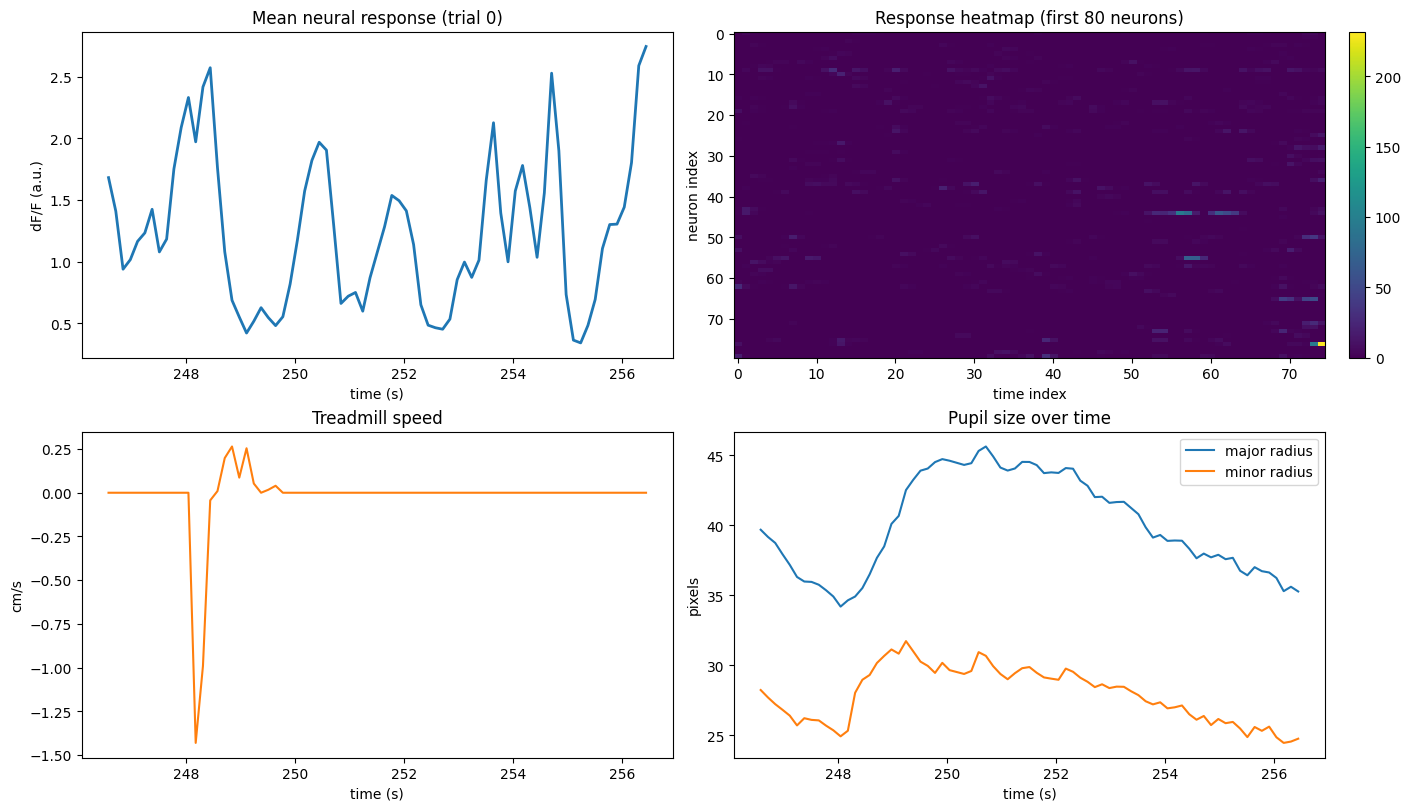

In [9]:
# Visualize one trial in more detail.
trial0 = full_data['trials'][0]
responses = trial0['responses']
treadmill = trial0['treadmill']
stim_times = trial0['stim_times']
pupil = trial0['pupil']

mean_trace = responses.mean(axis=0)
n_show = min(80, responses.shape[0])
heat = responses[:n_show, :]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(stim_times, mean_trace, lw=2)
axes[0, 0].set_title('Mean neural response (trial 0)')
axes[0, 0].set_xlabel('time (s)')
axes[0, 0].set_ylabel('dF/F (a.u.)')

im = axes[0, 1].imshow(heat, aspect='auto', interpolation='nearest', cmap='viridis')
axes[0, 1].set_title(f'Response heatmap (first {n_show} neurons)')
axes[0, 1].set_xlabel('time index')
axes[0, 1].set_ylabel('neuron index')
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].plot(stim_times, treadmill, color='tab:orange')
axes[1, 0].set_title('Treadmill speed')
axes[1, 0].set_xlabel('time (s)')
axes[1, 0].set_ylabel('cm/s')

axes[1, 1].plot(stim_times, pupil[2], label='major radius')
axes[1, 1].plot(stim_times, pupil[3], label='minor radius')
axes[1, 1].set_title('Pupil size over time')
axes[1, 1].set_xlabel('time (s)')
axes[1, 1].set_ylabel('pixels')
axes[1, 1].legend()

plt.show()

## Neural Activity and Behavior

The final comparison asks whether average neural activity changes with behavioral state. Here we compare mean response levels against average running and a simple proxy for pupil size across trials.

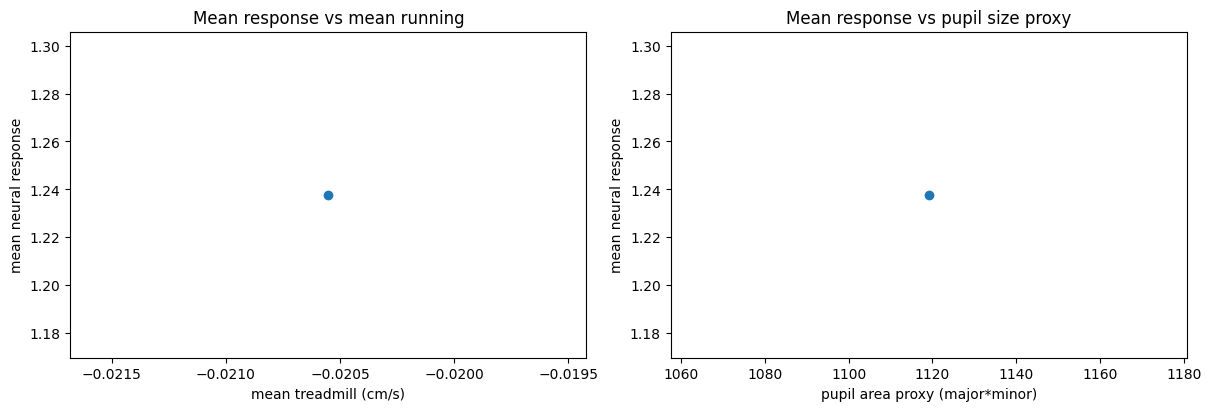

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session,1,1,5_6,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trial_idx,1.0,NaN,NaN,NaN,5.0,NaN,5.0,5.0,5.0,5.0,5.0
n_neurons,1.0,NaN,NaN,NaN,8592.0,NaN,8592.0,8592.0,8592.0,8592.0,8592.0
n_timepoints,1.0,NaN,NaN,NaN,75.0,NaN,75.0,75.0,75.0,75.0,75.0
mean_response,1.0,NaN,NaN,NaN,1.237777,NaN,1.237777,1.237777,1.237777,1.237777,1.237777
std_response,1.0,NaN,NaN,NaN,8.125614,NaN,8.125614,8.125614,8.125614,8.125614,8.125614
mean_treadmill_cm_s,1.0,NaN,NaN,NaN,-0.020551,NaN,-0.020551,-0.020551,-0.020551,-0.020551,-0.020551
max_treadmill_cm_s,1.0,NaN,NaN,NaN,0.264459,NaN,0.264459,0.264459,0.264459,0.264459,0.264459
mean_pupil_major,1.0,NaN,NaN,NaN,40.061821,NaN,40.061821,40.061821,40.061821,40.061821,40.061821
mean_pupil_minor,1.0,NaN,NaN,NaN,27.934376,NaN,27.934376,27.934376,27.934376,27.934376,27.934376


In [10]:
# Relationship between neural average and behavior across trials.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].scatter(trial_df['mean_treadmill_cm_s'], trial_df['mean_response'])
axes[0].set_xlabel('mean treadmill (cm/s)')
axes[0].set_ylabel('mean neural response')
axes[0].set_title('Mean response vs mean running')

pupil_area_proxy = trial_df['mean_pupil_major'] * trial_df['mean_pupil_minor']
axes[1].scatter(pupil_area_proxy, trial_df['mean_response'])
axes[1].set_xlabel('pupil area proxy (major*minor)')
axes[1].set_ylabel('mean neural response')
axes[1].set_title('Mean response vs pupil size proxy')

plt.show()

trial_df.describe(include='all').T